<a href="https://colab.research.google.com/github/tahajamshidi/DSA-210-Project/blob/main/DSA_210_project_stage_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Entering** **Data**

In [159]:
import pandas as pd
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

df = pd.read_csv("DSA210-project-data.csv")
df

,Year,Country,ISO3,GDP_Per_Capita,Population_Growth_Rate,Source
0,2000,Afghanistan,AFG,174.930991,NaN,World Bank API
1,2001,Afghanistan,AFG,116860.028200,1.666359,World Bank API
2,2002,Afghanistan,AFG,565.569730,NaN,World Bank API
3,2003,Afghanistan,AFG,40354.281030,-1.059785,World Bank API
4,2004,Afghanistan,AFG,2446.909499,-0.417931,World Bank API
...,...,...,...,...,...,...
5065,2021,Zimbabwe,ZWE,824.028192,1.402030,World Bank API
5066,2022,Zimbabwe,ZWE,2877.393314,-0.522606,World Bank API
5067,2023,Zimbabwe,ZWE,2578.666894,2.009991,World Bank API
5068,2024,Zimbabwe,ZWE,4009.320221,1.003451,World Bank API


**Cleaning Data**

In [160]:
# first of all, as we do not need the resource of the data, we can delete the column.
df = df[["Year", "Country", "GDP_Per_Capita", "Population_Growth_Rate"]]

length_before = len(df)
# deleting the missing values because of the errors they may make
df = df.dropna(subset=["GDP_Per_Capita", "Population_Growth_Rate"])
length_after = len(df)
# how may rows are deleted?
deleted_rows = length_before -  length_after
print(f"{deleted_rows} rows contined missing data which are eliminated")


26 rows contined missing data which are eliminated


**Enrichment**

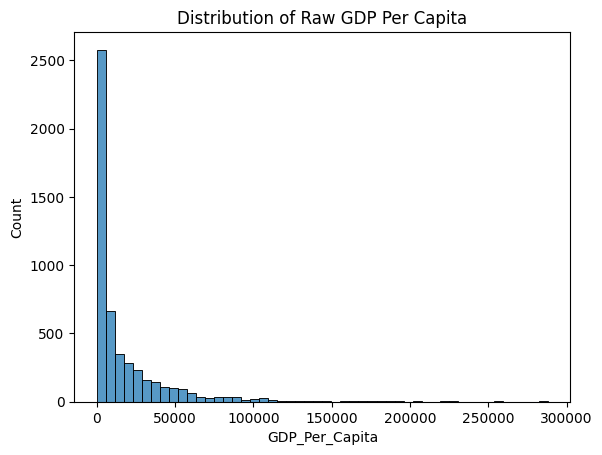

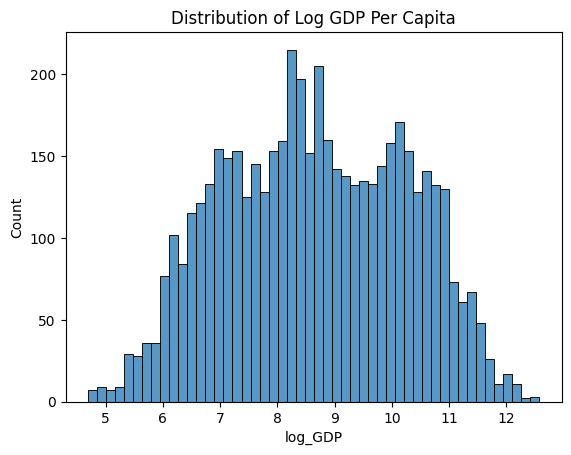

In [161]:
plt.figure()
sns.histplot(df["GDP_Per_Capita"], bins=50)
plt.title("Distribution of Raw GDP Per Capita")
plt.show()


df["log_GDP"] = np.log(df["GDP_Per_Capita"])
plt.figure()
sns.histplot(df["log_GDP"], bins=50)
plt.title("Distribution of Log GDP Per Capita")
plt.show()

As we can see here, the normal GDP_Per_Capita we have in our data:

1. distribution is highly right skewed
2. this histogram indicates the exponential distribution in this data

Both of the things above makes the work so harder for us in terms of interpreting the data + dificully in regression and forcasting

To be dealingw with these two problems, we use the log GDP method.
This method firstly made the distribution linear which is way easier while forecasting, etc., in addition to making the counts distribution standard normal which is most preferred in data analysis.


<Axes: title={'center': 'Raw GDP Per Capita Over Time'}, xlabel='Year'>

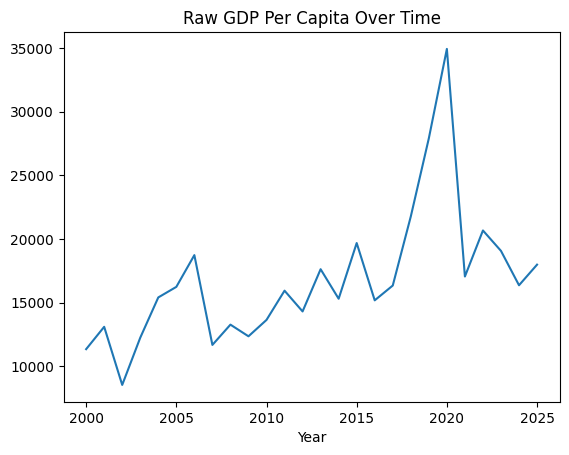

In [162]:
df.groupby("Year")["GDP_Per_Capita"].mean().plot(title="Raw GDP Per Capita Over Time")

<Axes: title={'center': 'Log GDP Per Capita Over Time'}, xlabel='Year'>

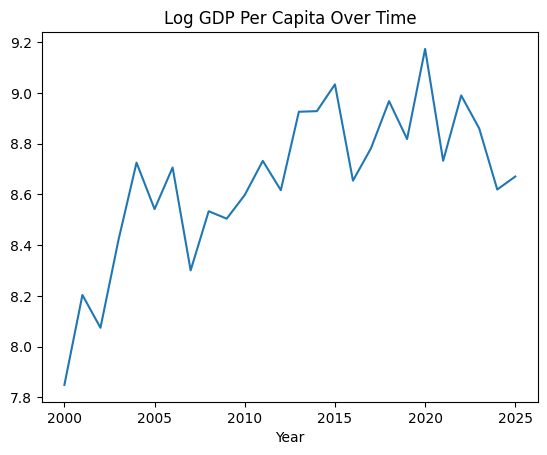

In [163]:
df.groupby("Year")["log_GDP"].mean().plot(title="Log GDP Per Capita Over Time")

In last two steps, we saw how data became more linear oriented rather than exponentialy.

Adding Log GDP and Categorizing in term of that, add the column representing if thr GDP of the country in the specific year was considered as High or Low to generally come up with that if the country is rich or poor generally.


In [164]:
# here we wanna categorize if the country had a low or high gdp in certain year and also add continents to be able to compare continentwise
# Calculate median GDP per year for the world
df["GDP_Year"] = df.groupby("Year")["GDP_Per_Capita"].transform("median")

# decide if the countrie's gdp was high or low with respect to the whole world year's gdp
df["GDP_Year"] = df.apply(lambda row: "High GDP" if row["GDP_Per_Capita"] > row["GDP_Year"] else "Low GDP", axis=1)

df


,Year,Country,GDP_Per_Capita,Population_Growth_Rate,log_GDP,GDP_Year
1,2001,Afghanistan,116860.028200,1.666359,11.668732,High GDP
3,2003,Afghanistan,40354.281030,-1.059785,10.605453,High GDP
4,2004,Afghanistan,2446.909499,-0.417931,7.802581,Low GDP
5,2005,Afghanistan,72004.743700,1.200776,11.184487,High GDP
6,2006,Afghanistan,6069.439031,-1.543137,8.711021,High GDP
...,...,...,...,...,...,...
5065,2021,Zimbabwe,824.028192,1.402030,6.714205,Low GDP
5066,2022,Zimbabwe,2877.393314,-0.522606,7.964640,Low GDP
5067,2023,Zimbabwe,2578.666894,2.009991,7.855028,Low GDP
5068,2024,Zimbabwe,4009.320221,1.003451,8.296377,Low GDP


Here, we wanna add the continent of the country. Later on, we can compare growth rates and GDP rates and their reations contienentwise as well.


In [165]:
continent_map = {
    "Africa": [
        "algeria","angola","benin","botswana","burkina faso","burundi","cameroon","cape verde",
        "central african republic","chad","comoros","congo","democratic republic of the congo",
        "djibouti","egypt","equatorial guinea","eritrea","eswatini","ethiopia","gabon","gambia",
        "ghana","guinea","guinea-bissau","ivory coast","kenya","lesotho","liberia","libya",
        "madagascar","malawi","mali","mauritania","mauritius","morocco","mozambique","namibia",
        "niger","nigeria","rwanda","sao tome and principe","senegal","seychelles","sierra leone",
        "somalia","south africa","south sudan","sudan","tanzania","togo","tunisia","uganda",
        "zambia","zimbabwe"
    ],

    "Asia": [
        "afghanistan","armenia","azerbaijan","bahrain","bangladesh","bhutan","brunei",
        "cambodia","china","cyprus","georgia","india","indonesia","iran","iraq","israel",
        "japan","jordan","kazakhstan","kuwait","kyrgyzstan","laos","lebanon","malaysia",
        "maldives","mongolia","myanmar","nepal","north korea","oman","pakistan",
        "palestine","philippines","qatar","saudi arabia","singapore","south korea",
        "sri lanka","syria","taiwan","tajikistan","thailand","timor-leste","turkey",
        "turkmenistan","united arab emirates","uzbekistan","vietnam","yemen"
    ],

    "Europe": [
        "albania","andorra","austria","belarus","belgium","bosnia and herzegovina","bulgaria",
        "croatia","czech republic","denmark","estonia","finland","france","germany","greece",
        "hungary","iceland","ireland","italy","kosovo","latvia","liechtenstein","lithuania",
        "luxembourg","malta","moldova","monaco","montenegro","netherlands","north macedonia",
        "norway","poland","portugal","romania","russia","san marino","serbia","slovakia",
        "slovenia","spain","sweden","switzerland","ukraine","united kingdom","vatican city"
    ],

    "North America": [
        "antigua and barbuda","bahamas","barbados","belize","canada","costa rica","cuba",
        "dominica","dominican republic","el salvador","grenada","guatemala","haiti",
        "honduras","jamaica","mexico","nicaragua","panama","saint kitts and nevis",
        "saint lucia","saint vincent and the grenadines","trinidad and tobago","united states"
    ],

    "South America": [
        "argentina","bolivia","brazil","chile","colombia","ecuador","guyana","paraguay",
        "peru","suriname","uruguay","venezuela"
    ],

    "Oceania": [
        "australia","fiji","kiribati","marshall islands","micronesia","nauru","new zealand",
        "palau","papua new guinea","samoa","solomon islands","tonga","tuvalu","vanuatu"
    ]
}

df["Country"] = df["Country"].str.lower()
country_to_continent = {}

for continent, countries in continent_map.items():
    for country in countries:
        country_to_continent[country] = continent
df["Continent"] = df["Country"].map(country_to_continent)



# check if there is any country or generally smth. missing in our continent_map

df[df["Continent"].isnull()]["Country"].unique()


array(['american samoa', 'aruba', 'bahamas, the', 'bermuda',
       'british virgin islands', 'brunei darussalam', 'cabo verde',
       'cayman islands', 'channel islands', 'congo, dem. rep.',
       'congo, rep.', "cote d'ivoire", 'curacao', 'czechia',
       'egypt, arab rep.', 'french polynesia', 'guam',
       'hong kong sar, china', 'iran, islamic rep.', 'isle of man',
       "korea, dem. people's rep.", 'kyrgyz republic', 'macao sar, china',
       'new caledonia', 'northern mariana islands', 'puerto rico (us)',
       'russian federation', 'sint maarten (dutch part)',
       'slovak republic', 'somalia, fed. rep.', 'st. lucia',
       'st. martin (french part)', 'st. vincent and the grenadines',
       'syrian arab republic', 'turkiye', 'turks and caicos islands',
       'venezuela, rb', 'viet nam', 'virgin islands (u.s.)',
       'west bank and gaza', 'yemen, rep.'], dtype=object)

In [166]:
fix_continent = {
    # North America (Caribbean + territories)
    "aruba": "North America",
    "bahamas, the": "North America",
    "bermuda": "North America",
    "british virgin islands": "North America",
    "cayman islands": "North America",
    "curacao": "North America",
    "puerto rico (us)": "North America",
    "sint maarten (dutch part)": "North America",
    "st. lucia": "North America",
    "st. martin (french part)": "North America",
    "st. vincent and the grenadines": "North America",
    "turks and caicos islands": "North America",
    "virgin islands (u.s.)": "North America",

    # Africa
    "cabo verde": "Africa",
    "congo, dem. rep.": "Africa",
    "congo, rep.": "Africa",
    "cote d'ivoire": "Africa",
    "egypt, arab rep.": "Africa",
    "somalia, fed. rep.": "Africa",

    # Asia
    "brunei darussalam": "Asia",
    "hong kong sar, china": "Asia",
    "iran, islamic rep.": "Asia",
    "korea, dem. people's rep.": "Asia",
    "kyrgyz republic": "Asia",
    "macao sar, china": "Asia",
    "syrian arab republic": "Asia",
    "viet nam": "Asia",
    "yemen, rep.": "Asia",

    # Europe
    "channel islands":"Europe",
    "isle of man":"Europe",
    "slovak republic":"Europe",
    "czechia": "Europe",
    "russian federation":"Europe",

    # Oceania
    "american samoa": "Oceania",
    "french polynesia": "Oceania",
    "guam": "Oceania",
    "new caledonia": "Oceania",
    "northern mariana islands": "Oceania",

    # South America
    "venezuela, rb": "South America",


    "west bank and gaza": "Asia",
    "turkiye":"Euroupe"
}
df["Continent"] = df["Continent"].fillna(df["Country"].map(fix_continent))




# final check to get sure there is not country mising
df[df["Continent"].isnull()]["Country"].unique()
# output is empthy meaning that everything aboit assigning the contienents are fiixed


array([], dtype=object)

In [167]:
df

,Year,Country,GDP_Per_Capita,Population_Growth_Rate,log_GDP,GDP_Year,Continent
1,2001,afghanistan,116860.028200,1.666359,11.668732,High GDP,Asia
3,2003,afghanistan,40354.281030,-1.059785,10.605453,High GDP,Asia
4,2004,afghanistan,2446.909499,-0.417931,7.802581,Low GDP,Asia
5,2005,afghanistan,72004.743700,1.200776,11.184487,High GDP,Asia
6,2006,afghanistan,6069.439031,-1.543137,8.711021,High GDP,Asia
...,...,...,...,...,...,...,...
5065,2021,zimbabwe,824.028192,1.402030,6.714205,Low GDP,Africa
5066,2022,zimbabwe,2877.393314,-0.522606,7.964640,Low GDP,Africa
5067,2023,zimbabwe,2578.666894,2.009991,7.855028,Low GDP,Africa
5068,2024,zimbabwe,4009.320221,1.003451,8.296377,Low GDP,Africa


**EDA**

In [168]:
df.describe()

,Year,GDP_Per_Capita,Population_Growth_Rate,log_GDP
count,5044.000000,5044.000000,5044.000000,5044.000000
mean,2012.558089,16833.082100,1.263559,8.655219
std,7.475812,26887.201474,1.590013,1.580067
min,2000.000000,109.593814,-11.356645,4.696781
25%,2006.000000,1623.910426,0.329386,7.392592
50%,2013.000000,5601.960819,1.178398,8.630872
75%,2019.000000,20930.582120,2.135724,9.948967
max,2025.000000,288001.433400,21.700343,12.570721


As we can see, there are some outliers here. But for now I decided to keep them, because I want to compaire for example countinent with each other in this concept and small countries with high GDP, like Monaco, are gonna affect the result. So, naybe later I eliminate the outlier for regression purposes, etc. But now we will use median instead of mean in order not to be sensitive to outliers.

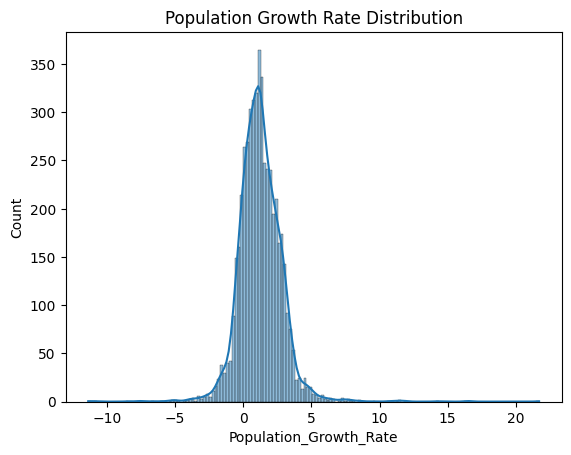

In [169]:
sns.histplot(df["Population_Growth_Rate"], kde=True)
plt.title("Population Growth Rate Distribution")
plt.show()

We do see that population growth rate also follows a standard normal distribution with the mean around 1.5.

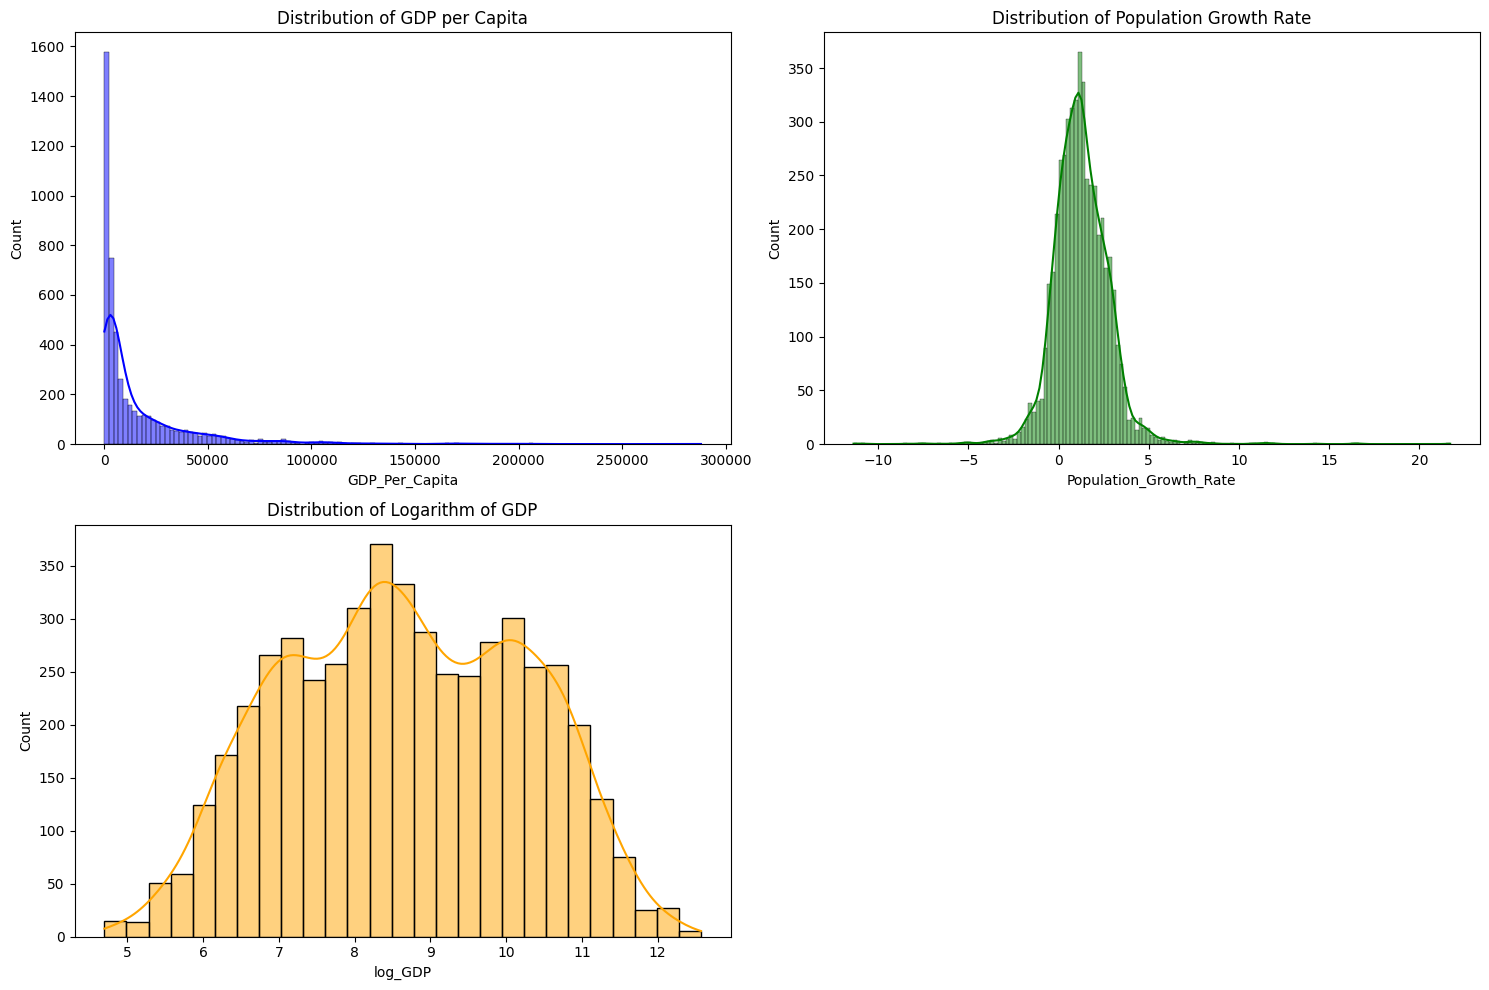

In [170]:

# Set up the figure
plt.figure(figsize=(15, 10))

# Plot histograms for important numerical features
plt.subplot(2, 2, 1)
sns.histplot(df['GDP_Per_Capita'], kde=True, color='blue')
plt.title('Distribution of GDP per Capita')

plt.subplot(2, 2, 2)
sns.histplot(df['Population_Growth_Rate'], kde=True, color='green')
plt.title('Distribution of Population Growth Rate')

plt.subplot(2, 2, 3)
sns.histplot(df['log_GDP'], kde=True, color='orange')
plt.title('Distribution of Logarithm of GDP')

# Display the plots
plt.tight_layout()
plt.show()

Visualizations on GDP_Per_Capita and Population_Growth_Rate in different continents.


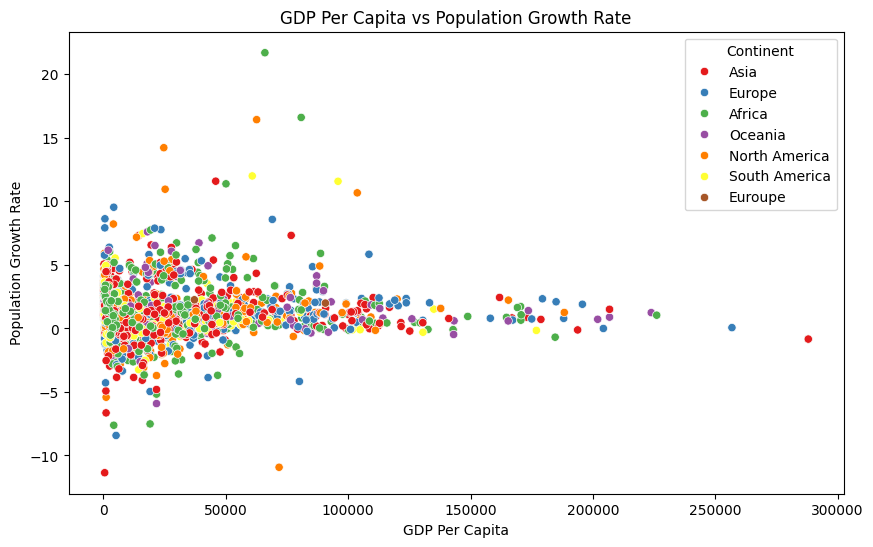

In [171]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='GDP_Per_Capita', y='Population_Growth_Rate', hue='Continent', palette='Set1')
plt.title('GDP Per Capita vs Population Growth Rate')
plt.xlabel('GDP Per Capita')
plt.ylabel('Population Growth Rate')
plt.show()

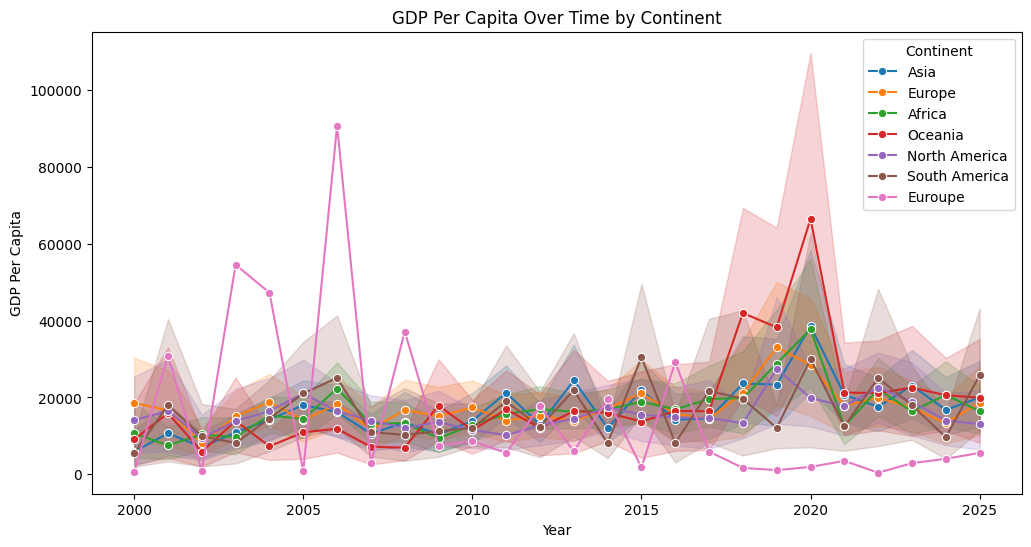

In [172]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Year', y='GDP_Per_Capita', hue='Continent', marker='o')
plt.title('GDP Per Capita Over Time by Continent')
plt.xlabel('Year')
plt.ylabel('GDP Per Capita')
plt.show()

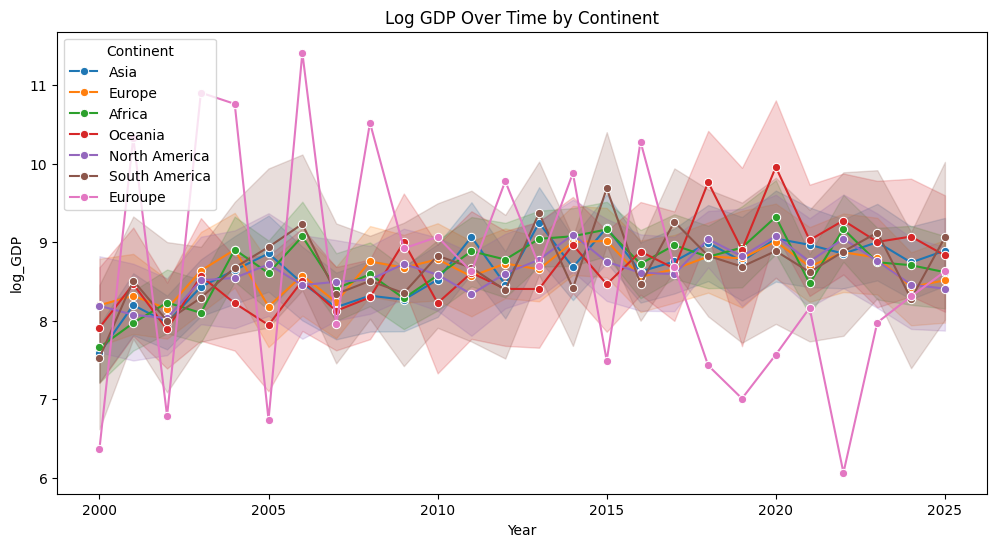

In [173]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Year', y='log_GDP', hue='Continent', marker='o')
plt.title('Log GDP Over Time by Continent')
plt.xlabel('Year')
plt.ylabel('log_GDP')
plt.show()

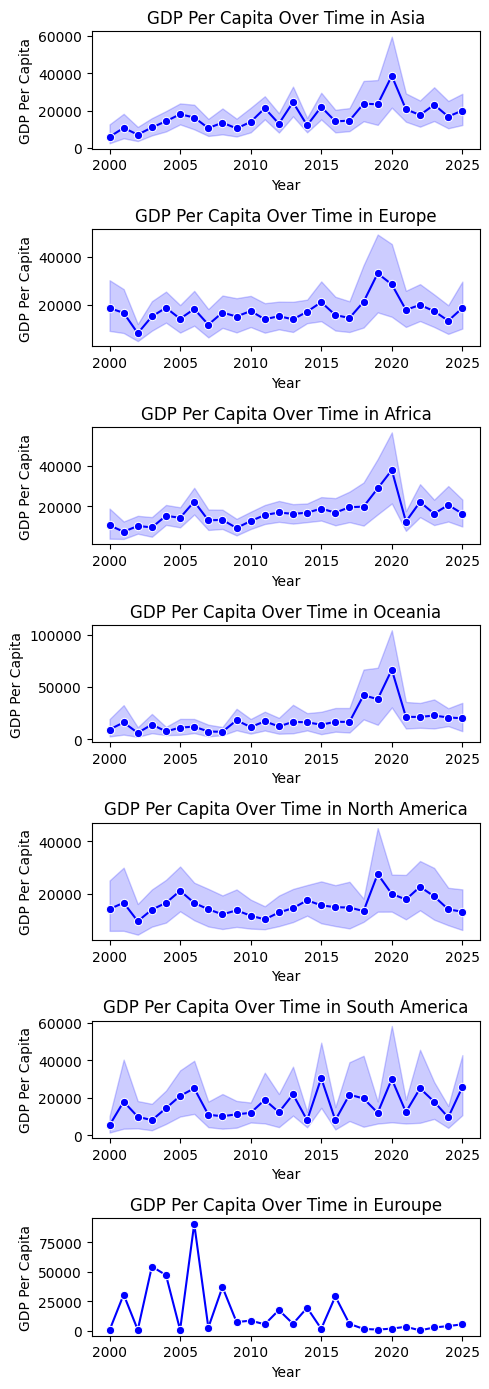

In [174]:
# Set up a grid of subplots (one for each continent)
continents = df['Continent'].unique()
num_continents = len(continents)

# Create subplots
fig, axes = plt.subplots(num_continents, 1, figsize=(5, 2 * num_continents))

# Loop through each continent and plot its GDP per Capita in a separate subplot
for i, continent in enumerate(continents):
    # Filter data for the continent
    continent_data = df[df['Continent'] == continent]

    # Plot GDP per Capita for this continent
    sns.lineplot(data=continent_data, x='Year', y='GDP_Per_Capita', ax=axes[i], color='blue', marker='o')

    # Add titles and labels
    axes[i].set_title(f'GDP Per Capita Over Time in {continent}')
    axes[i].set_xlabel('Year')
    axes[i].set_ylabel('GDP Per Capita')

# Adjust layout to avoid overlap
plt.tight_layout()
plt.show()

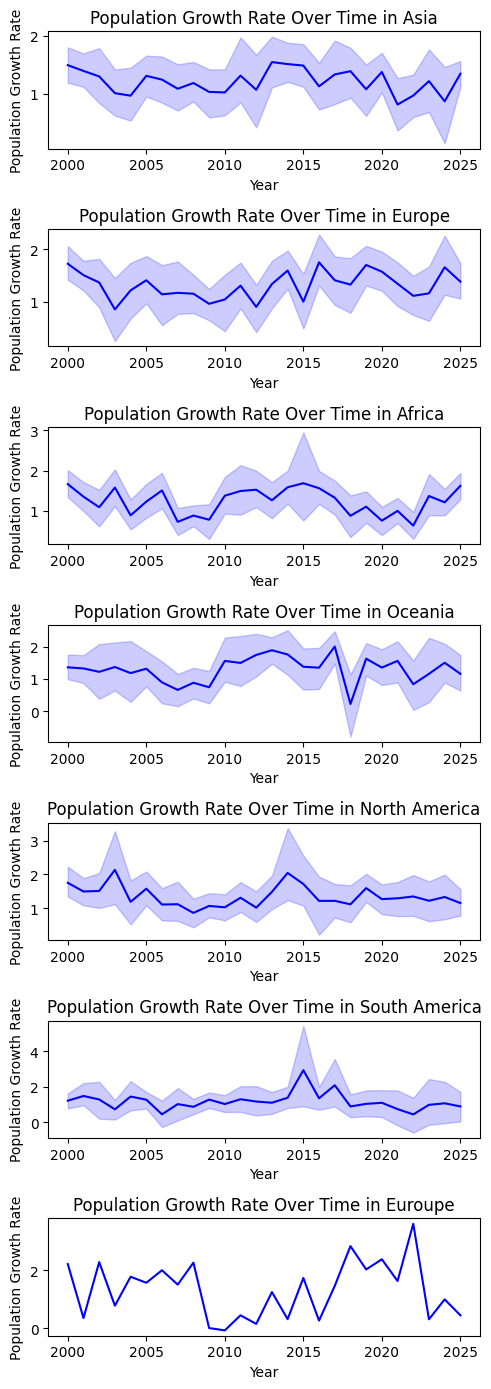

In [156]:
# Set up a grid of subplots (one for each continent)
continents = df['Continent'].unique()
num_continents = len(continents)

# Create subplots
fig, axes = plt.subplots(num_continents, 1, figsize=(5, 2 * num_continents))

# Loop through each continent and plot its population growth rate in a separate subplot
for i, continent in enumerate(continents):
    # Filter data for the continent
    continent_data = df[df['Continent'] == continent]

    # Plot Population Growth Rate for this continent
    sns.lineplot(data=continent_data, x='Year', y='Population_Growth_Rate', ax=axes[i], color='blue')

    # Add titles and labels
    axes[i].set_title(f'Population Growth Rate Over Time in {continent}')
    axes[i].set_xlabel('Year')
    axes[i].set_ylabel('Population Growth Rate')

# Adjust layout to avoid overlap
plt.tight_layout()
plt.show()

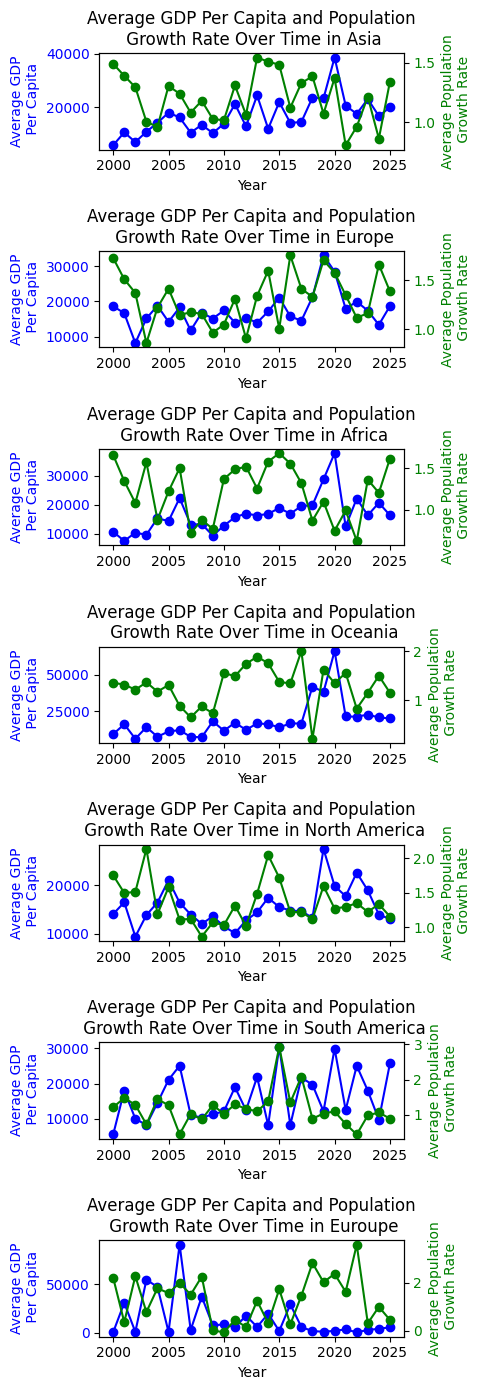

In [186]:
# Set up a grid of subplots (one for each continent)
continents = df['Continent'].unique()
num_continents = len(continents)

# Create subplots
fig, axes = plt.subplots(num_continents, 1, figsize=(5, 2
                                                     * num_continents))

# Loop through each continent and plot both GDP and Population Growth Rate on the same plot
for i, continent in enumerate(continents):
    # Group by Year and calculate the average for GDP per Capita and Population Growth Rate for each continent
    continent_data = df[df['Continent'] == continent]
    avg_data = continent_data.groupby('Year')[['GDP_Per_Capita', 'Population_Growth_Rate']].mean().reset_index()

    # Create a plot with dual y-axes
    ax1 = axes[i]
    # Plot GDP per Capita on the left y-axis
    ax1.plot(avg_data['Year'], avg_data['GDP_Per_Capita'], color='blue', label='Average GDP Per Capita', marker='o')
    ax1.set_xlabel('Year')
    ax1.set_ylabel('Average GDP\n Per Capita', color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')

    # Create a second y-axis for Population Growth Rate
    ax2 = ax1.twinx()
    ax2.plot(avg_data['Year'], avg_data['Population_Growth_Rate'], color='green', label='Average Population Growth Rate', marker='o')
    ax2.set_ylabel('Average Population\n Growth Rate', color='green')
    ax2.tick_params(axis='y', labelcolor='green')

    # Add title
    ax1.set_title(f'Average GDP Per Capita and Population\n Growth Rate Over Time in {continent}')

# Adjust layout to avoid overlap
plt.tight_layout()
plt.show()

First Hypothesis Testing:

H0= There is no significant relation between GDP per capita and Population growth rate.

H1= There is a significant relation between GDP per capita and population growth rate.

In [145]:
from scipy.stats import pearsonr

# Perform Pearson correlation test
correlation, p_value = pearsonr(df['GDP_Per_Capita'], df['Population_Growth_Rate'])

# Output the results
print(f"Pearson Correlation: {correlation}")
print(f"P-value: {p_value}")

# Interpret the result
if p_value < 0.05:
    print("The correlation is statistically significant (reject H0).")
else:
    print("The correlation is not statistically significant (fail to reject H0).")

Pearson Correlation: -0.07569881415447346
P-value: 7.34149487476245e-08
The correlation is statistically significant (reject H0).


In this method, if the p-value is less than 0.05, we do reject the H0.

Second Hypothesis Testing:

H0 = There is no significant relation between log-GDP and Population growth rate.

H1 = There is a significant relation between log-GDP and Population growth rate.

In [146]:
# Perform Pearson correlation test with log_GDP
correlation_log, p_value_log = pearsonr(df['log_GDP'], df['Population_Growth_Rate'])

# Output the results
print(f"Pearson Correlation (log GDP vs Population Growth Rate): {correlation_log}")
print(f"P-value: {p_value_log}")

# Interpret the result
if p_value_log < 0.05:
    print("The correlation is statistically significant (reject H0).")
else:
    print("The correlation is not statistically significant (fail to reject H0).")

Pearson Correlation (log GDP vs Population Growth Rate): -0.27348655781223363
P-value: 3.152602640762998e-87
The correlation is statistically significant (reject H0).


Third Hypothesis Testing:

H0 = The mean population growth rate is not too much fifferent across all continents.

H1 = The mean population growth rate differs significantly across at least one continent.

In [149]:
from scipy.stats import f_oneway
import scipy.stats as stats

# Group the data by continent
asia = df[df['Continent'] == 'Asia']['Population_Growth_Rate']
africa = df[df['Continent'] == 'Africa']['Population_Growth_Rate']
europe = df[df['Continent'] == 'Europe']['Population_Growth_Rate']
north_america = df[df['Continent'] == 'North America']['Population_Growth_Rate']
south_america = df[df['Continent'] == 'South America']['Population_Growth_Rate']
oceania = df[df['Continent'] == 'Oceania']['Population_Growth_Rate']

# Perform the ANOVA test
f_stat, p_value_anova = stats.f_oneway(asia, africa, europe, north_america, south_america, oceania)

# Print out the results
print(f"ANOVA F-statistic: {f_stat}")
print(f"P-value for ANOVA: {p_value_anova}")
# Interpret the result
if p_value_anova < 0.05:
    print("The population growth rate differs significantly across continents (reject H0).")
else:
    print("The population growth rate does not differ significantly across continents (fail to reject H0).")

ANOVA F-statistic: 1.3575706039016082
P-value for ANOVA: 0.2371045050762398
The population growth rate does not differ significantly across continents (fail to reject H0).
